# Phase III: First ML Proof of Concept (5\%)

### Team Names:
- Gokul Ramanan
- Fanny Cao
- Gensen
- Haojin

In [1]:
!pip install wbdata

In [2]:
# Importing Necessary Libraries
import wbdata as wb
import pandas as pd
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

In [3]:
def clean_data(countries, indicators, year_start, year_end):
  """
    Fetch and preprocess World Bank indicator data for specified countries and years.

    This function retrieves data from the World Bank API for the given indicators and countries,
    converts the date column to integer years, and filters the results to include only data within
    the specified year range.

    Parameters
    ----------
    countries : list of str
        A list of country codes (e.g., ["IN", "US", "CN"]) to retrieve data for.
    indicators : dict
        A dictionary mapping indicator names to World Bank indicator codes.
        Example: {"GDP per capita": "NY.GDP.PCAP.CD"}
    year_start : int
        The starting year of the desired time range.
    year_end : int
        The ending year of the desired time range.

    Returns
    -------
    pandas.DataFrame
        A cleaned DataFrame containing country, date (year), and indicator values
        filtered to the specified range, with a flat index for easier use.
  """

  data = wb.get_dataframe(indicators, country=countries).reset_index()
  data["date"] = data["date"].astype(int)
  data = data[(data["date"] <= year_end) & (data["date"] >= year_start)]
  data = data.dropna(axis=1, thresh= 0.9 * len(data))
  data["country-year"] = data["country"] + " " + data["date"].astype(str)
  data = data.sort_values(by=["country", "date"])

  return data

In [4]:
# List of the top 20 countries ranked by GDP in 2024
# (using ISO-3 country codes as defined by the World Bank API)

countries = ["US", "CN", "DE", "JP", "IN", "GB", "FR", "IT", "CA", "BR", "RU", "MX",
             "AU", "ES", "KR", "ID", "TR", "SA", "NL", "CH"]

# Dictionary of World Bank indicators for GDP growth prediction
# Key = World Bank indicator code
# Value = Custom short name
# Units commented next to each indicator

indicators = {
    # Demographics & Population
    "EN.POP.DNST": "population_density",       # people per sq. km of land area
    "SP.POP.TOTL": "total_population",         # number of people
    "SP.URB.TOTL.IN.ZS": "urban_population_pct", # % of total population living in urban areas
    "SP.DYN.TFRT.IN": "fertility_rate",        # births per woman
    "SP.POP.DPND": "age_dependency_ratio",     # % of working-age population (dependents per 100 working-age people)

    # Health & Capital
    "SP.DYN.LE00.IN": "life_expectancy",       # years
    "SP.DYN.IMRT.IN": "infant_mortality",      # per 1,000 live births
    "SH.XPD.CHEX.PC.CD": "health_exp_pc",      # US$ per capita (current)
    "SH.XPD.CHEX.GD.ZS": "health_exp_gdp_pct", # % of GDP

    # Education System
    "SE.ADT.LITR.ZS": "adult_literacy",        # % of people ages 15+
    "SE.PRM.ENRR": "primary_school_enroll",    # % gross enrollment ratio
    "SE.SEC.ENRR": "secondary_school_enroll",  # % gross enrollment ratio
    "SE.TER.ENRR": "tertiary_school_enroll",   # % gross enrollment ratio
    "SE.XPD.TOTL.GD.ZS": "edu_exp_gdp_pct",    # % of GDP spent on education

    # Economy & Market Growth
    "NY.GDP.PCAP.CD": "gdp_per_capita",        # current US$
    "NE.GDI.TOTL.ZS": "gross_capital_form_pct",# % of GDP (investment)
    "FP.CPI.TOTL.ZG": "inflation_rate",        # annual %, consumer prices
    "SL.UEM.TOTL.ZS": "unemployment_rate",     # % of total labor force
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",         # % of GDP (exports + imports)
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_pct"  # % of GDP (net inflows of FDI)
}

In [5]:
# We want the dataset to include only years between 1980 and 2022
cleaned_data = clean_data(countries, indicators, 1980, 2022)
cleaned_data["gdp_growth"] = cleaned_data.groupby("country")["gdp_per_capita"].pct_change() * 100

# Scale numerical columns that aren't normalized
numeric_cols = ["gdp_per_capita", "total_population"]
scaler = MinMaxScaler()
cleaned_data[numeric_cols] = scaler.fit_transform(cleaned_data[numeric_cols])

# Create numerical country codes for countries
cleaned_data["country_code"] = cleaned_data["country"].astype("category").cat.codes

print(f"The data has {cleaned_data.shape[1]} features and {cleaned_data.shape[0]} observations.")

# Save the cleaned data into a csv for reuseability for ML practice
cleaned_data.to_csv("top20_gdp_indicators_1980_2022.csv", index=False)

The data has 17 features and 860 observations.


C:\Users\evanb\AppData\Local\Temp\ipykernel_60924\557482700.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data["gdp_growth"] = cleaned_data.groupby("country")["gdp_per_capita"].pct_change() * 100


In [6]:
gdp_clean_data = pd.read_csv("top20_gdp_indicators_1980_2022.csv")
gdp_clean_data.head()

,country,date,population_density,total_population,urban_population_pct,fertility_rate,age_dependency_ratio,life_expectancy,infant_mortality,gdp_per_capita,gross_capital_form_pct,inflation_rate,trade_pct_gdp,fdi_inflows_pct,country-year,gdp_growth,country_code
0,Australia,1980,1.912448,0.006090,85.552,1.891,53.522721,74.333659,10.8,0.106303,27.086336,10.135841,32.298275,1.244251,Australia 1980,NaN,0
1,Australia,1981,1.942551,0.006253,85.700,1.935,53.127055,74.663415,10.4,0.123764,28.676818,9.487666,31.603439,1.326516,Australia 1981,16.112228,0
2,Australia,1982,1.976524,0.006437,85.670,1.929,52.700172,74.904878,10.1,0.133589,29.833959,11.351820,30.324690,1.178263,Australia 1982,7.807511,0
3,Australia,1983,2.003758,0.006584,85.641,1.924,52.203948,75.146341,9.8,0.120177,25.301720,10.038911,29.175246,1.687262,Australia 1983,-9.886431,0
4,Australia,1984,2.027959,0.006715,85.611,1.840,51.652832,75.387805,9.6,0.129796,26.629791,3.960396,28.540008,0.221289,Australia 1984,7.868673,0


## Part 1
(3%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot, shapiro
import numpy as np

### Attempt 1 - Linear Regression

In [8]:
def fit_linear_regression(X, y):
    """
    Fit a linear regression model using the normal equation.

    Args:
        X (array): Feature matrix (n_samples, n_features)
        y (array): Target vector (n_samples,)

    Returns:
        tuple: (intercept, coefficients)
    """
    # Add intercept term (column of ones)
    X_with_intercept = np.c_[np.ones(X.shape[0]), X]

    # Normal equation: theta = (X^T X)^-1 X^T y
    theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

    intercept = theta[0]
    coefficients = theta[1:]

    return intercept, coefficients

In [9]:
def predict(X, intercept, coefficients):
    """
    Make predictions using the fitted model.

    Args:
        X (array): Feature matrix (n_samples, n_features)
        intercept (float): Model intercept
        coefficients (array): Model coefficients

    Returns:
        array: Predicted values
    """
    return X @ coefficients + intercept

In [10]:
def calculate_mse(y_true, y_pred):
    """
    Calculate Mean Squared Error.

    Args:
        y_true (array): True values
        y_pred (array): Predicted values

    Returns:
        float: MSE value
    """
    return np.mean((y_true - y_pred) ** 2)

In [11]:
def calculate_r2(y_true, y_pred):
    """
    Calculate R^2 score.

    Args:
        y_true (array): True values
        y_pred (array): Predicted values

    Returns:
        float: R² value
    """
    mse = calculate_mse(y_true, y_pred)
    return 1 - (mse / np.var(y_true))

In [12]:
def train_test_split_temporal(df, train_end_year=2015):
    """
    Split data temporally - training on early years, testing on later years.

    Args:
        df (DataFrame): Input dataframe
        train_end_year (int): Last year to include in training set

    Returns:
        tuple: (train_mask, test_mask) boolean arrays
    """
    train_mask = df['date'] <= train_end_year
    test_mask = df['date'] > train_end_year

    return train_mask, test_mask

In [13]:
def standardize_features(X_train, X_test):
    """
    Standardize features using training set statistics.

    Args:
        X_train (array): Training features
        X_test (array): Test features

    Returns:
        tuple: (X_train_std, X_test_std)
    """
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std

    return X_train_std, X_test_std

# Attempt 2 - Logarithmic Regression

In [14]:
def fit_semilog_regression(X, y):
    """
    Fits a semi-log regression: log(y) = β0 + β1*x1 + ... + βn*xn
    This captures exponential relationships without forcing log on features.

    Args:
        X (array): the feature matrix of predictor values (n_samples, n_features)
        y (array): the target vector corresponding with the predictor values (n_samples)

    Returns:
        tuple: (intercept, coefficients)
    """
    # Only log-transform the target
    y_log = np.log(y)

    # Add bias term (column of ones)
    X_with_bias = np.c_[np.ones(X.shape[0]), X]

    # Normal equation: theta = (X^T X)^-1 X^T y_log
    theta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y_log

    intercept = theta[0]
    coefficients = theta[1:]

    return intercept, coefficients

In [15]:
def predict_semilog_regression(X, intercept, coefficients):
    """
    Computes predictions for semi-log model and transforms back to original scale.

    Args:
        X (array): Feature matrix (n_samples, n_features) - NOT log transformed
        intercept (float): Model intercept
        coefficients (array): Model coefficients

    Returns:
        ypreds (array): Predicted values in original scale
    """
    # Compute log predictions using untransformed features
    ypreds_log = X @ coefficients + intercept

    # Transform back to original scale
    ypreds = np.exp(ypreds_log)

    return ypreds

In [16]:
def evaluate_model(X_train, X_test, y_train, y_test, feature_names, model_type='linear'):
    """
    Fit a regression model and evaluate performance.

    Args:
        X_train (array): Training features
        X_test (array): Test features
        y_train (array): Training target
        y_test (array): Test target
        feature_names (list): Names of features for interpretation
        model_type (str): the type of model of regression ('linear' or 'log')

    Returns:
        tuple: (intercept, coefficients, X_shift) for log, (intercept, coefficients, None) for linear
    """

    if model_type == 'linear':
        # Train the model
        intercept, coefficients = fit_linear_regression(X_train, y_train)
        # Predictions
        y_pred_train = predict(X_train, intercept, coefficients)
        y_pred_test = predict(X_test, intercept, coefficients)
    else:
        intercept, coefficients = fit_semilog_regression(X_train, y_train)
        # Predictions
        y_pred_train = predict_semilog_regression(X_train, intercept, coefficients)
        y_pred_test = predict_semilog_regression(X_test, intercept, coefficients)

    # Model evaluation
    mse_train = calculate_mse(y_train, y_pred_train)
    mse_test = calculate_mse(y_test, y_pred_test)

    r2_train = calculate_r2(y_train, y_pred_train)
    r2_test = calculate_r2(y_test, y_pred_test)

    return intercept, coefficients, mse_train, mse_test, r2_train, r2_test, y_pred_test

In [17]:
def plot_diagnostics(y_test, y_pred_test, title):
    """
    Create diagnostic plots for regression model.

    Args:
        y_test (array): True test values
        y_pred_test (array): Predicted test values
        title (str): Title for the plots
    """
    residuals = y_test - y_pred_test

    plt.figure(figsize=(16, 12))

    # 1. Residuals vs Fitted
    plt.subplot(2, 3, 1)
    plt.scatter(y_pred_test, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.title('Residuals vs Fitted Values')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(alpha=0.3)

    # 2. Residuals vs Order
    plt.subplot(2, 3, 2)
    plt.scatter(range(len(residuals)), residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel("Observation Index")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Order")
    plt.grid(alpha=0.3)

    # 3. Q-Q Plot
    plt.subplot(2, 3, 3)
    probplot(residuals, dist="norm", plot=plt)
    plt.title('Normal Q-Q Plot')
    plt.grid(alpha=0.3)

    # 4. Histogram of Residuals
    plt.subplot(2, 3, 4)
    plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu)**2 / (2 * sigma**2)),
             'r-', linewidth=2, label='Normal Distribution')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)

    # 5. Actual vs Predicted
    plt.subplot(2, 3, 5)
    plt.scatter(y_test, y_pred_test, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual GDP per Capita (scaled)')
    plt.ylabel('Predicted GDP per Capita (scaled)')
    plt.title('Actual vs Predicted Values')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

Training set size: 660 samples (1980-2015)
Testing set size:  139 samples (2016-2022)
LINEAR REGRESSION
Training MSE: 0.010619
Testing MSE:  0.029133
Training R^2:  0.6828
Testing R^2:   0.4944

Features ranked by importance:
1. life_expectancy          : 0.182865
2. infant_mortality         : 0.072214
3. date                     : 0.041204
4. total_population         : 0.027448
5. population_density       : 0.010792
6. age_dependency_ratio     : 0.009714
7. gdp_growth               : 0.001974
8. inflation_rate           : 0.000121


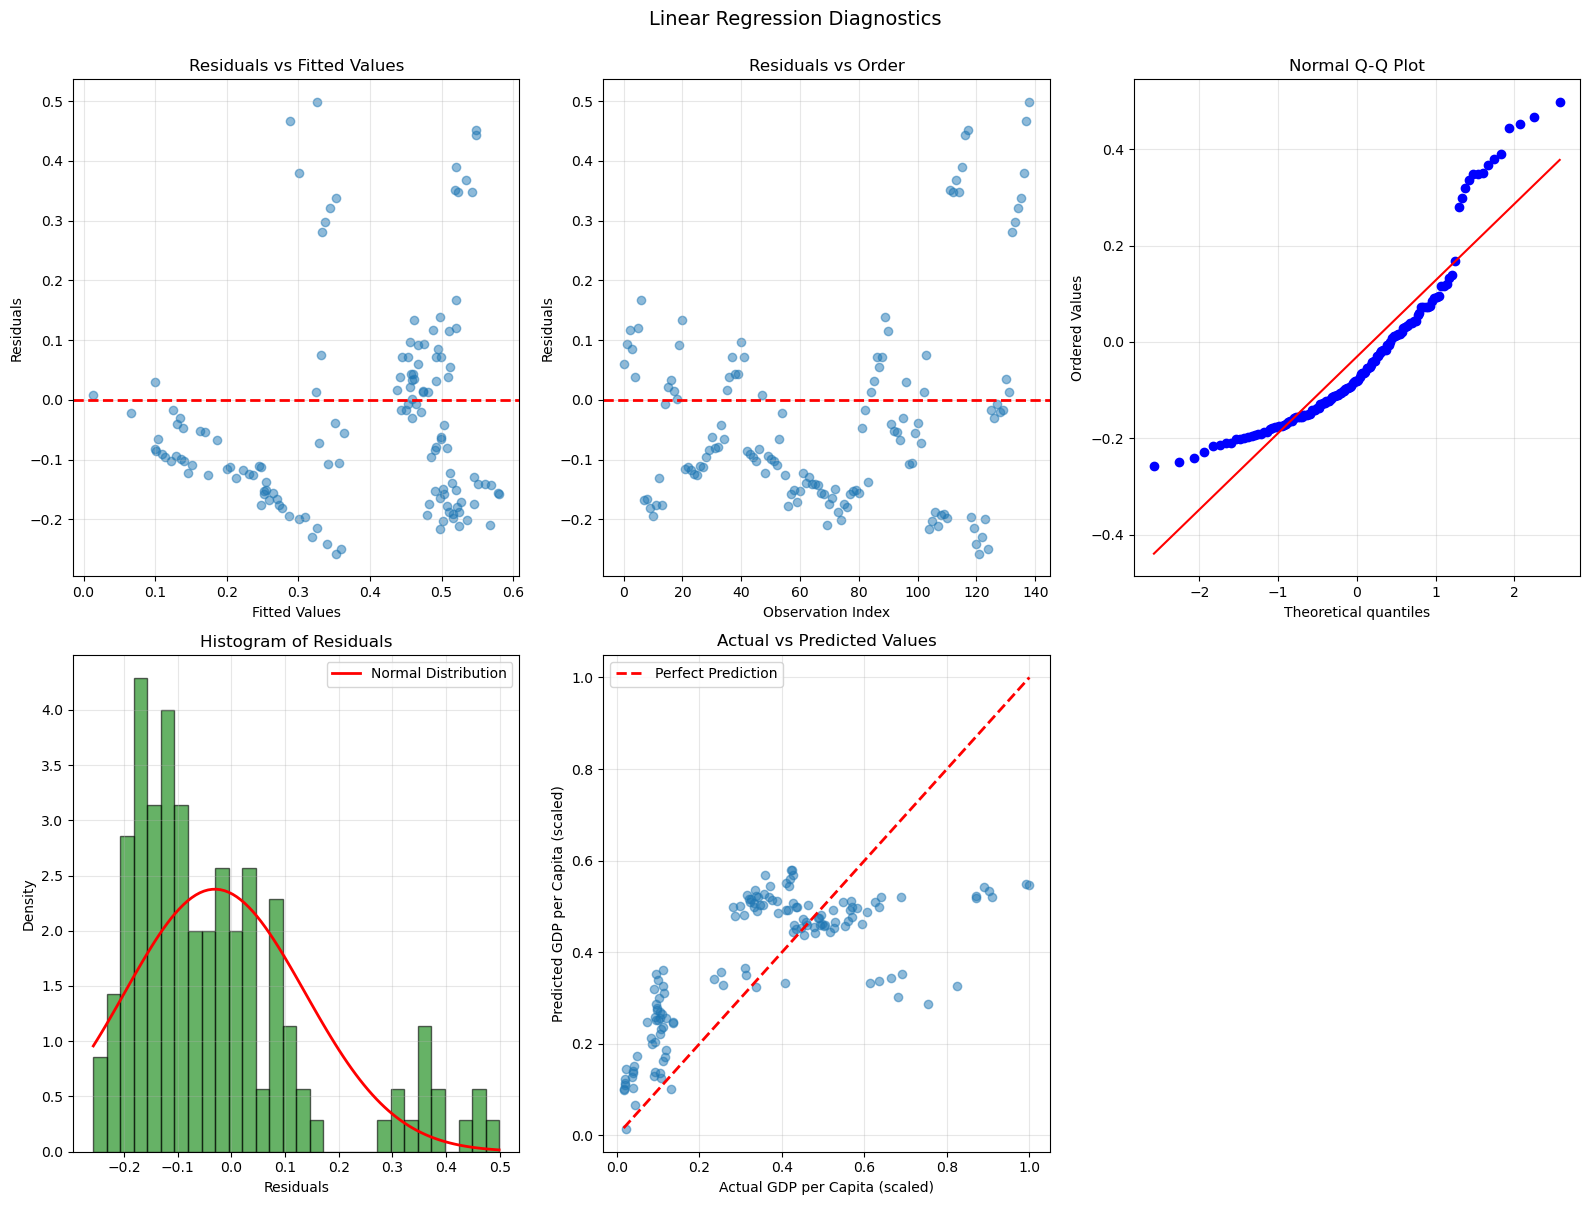

SEMI-LOG REGRESSION (log y, linear X)
Training MSE: 0.009043
Testing MSE:  0.045110
Training R²:  0.7298
Testing R²:   0.2172

Features ranked by importance:
1. life_expectancy          : 0.897370
2. infant_mortality         : 0.455384
3. total_population         : 0.306338
4. age_dependency_ratio     : 0.096223
5. date                     : 0.088936
6. gdp_growth               : 0.043408
7. inflation_rate           : 0.036699
8. population_density       : 0.028152


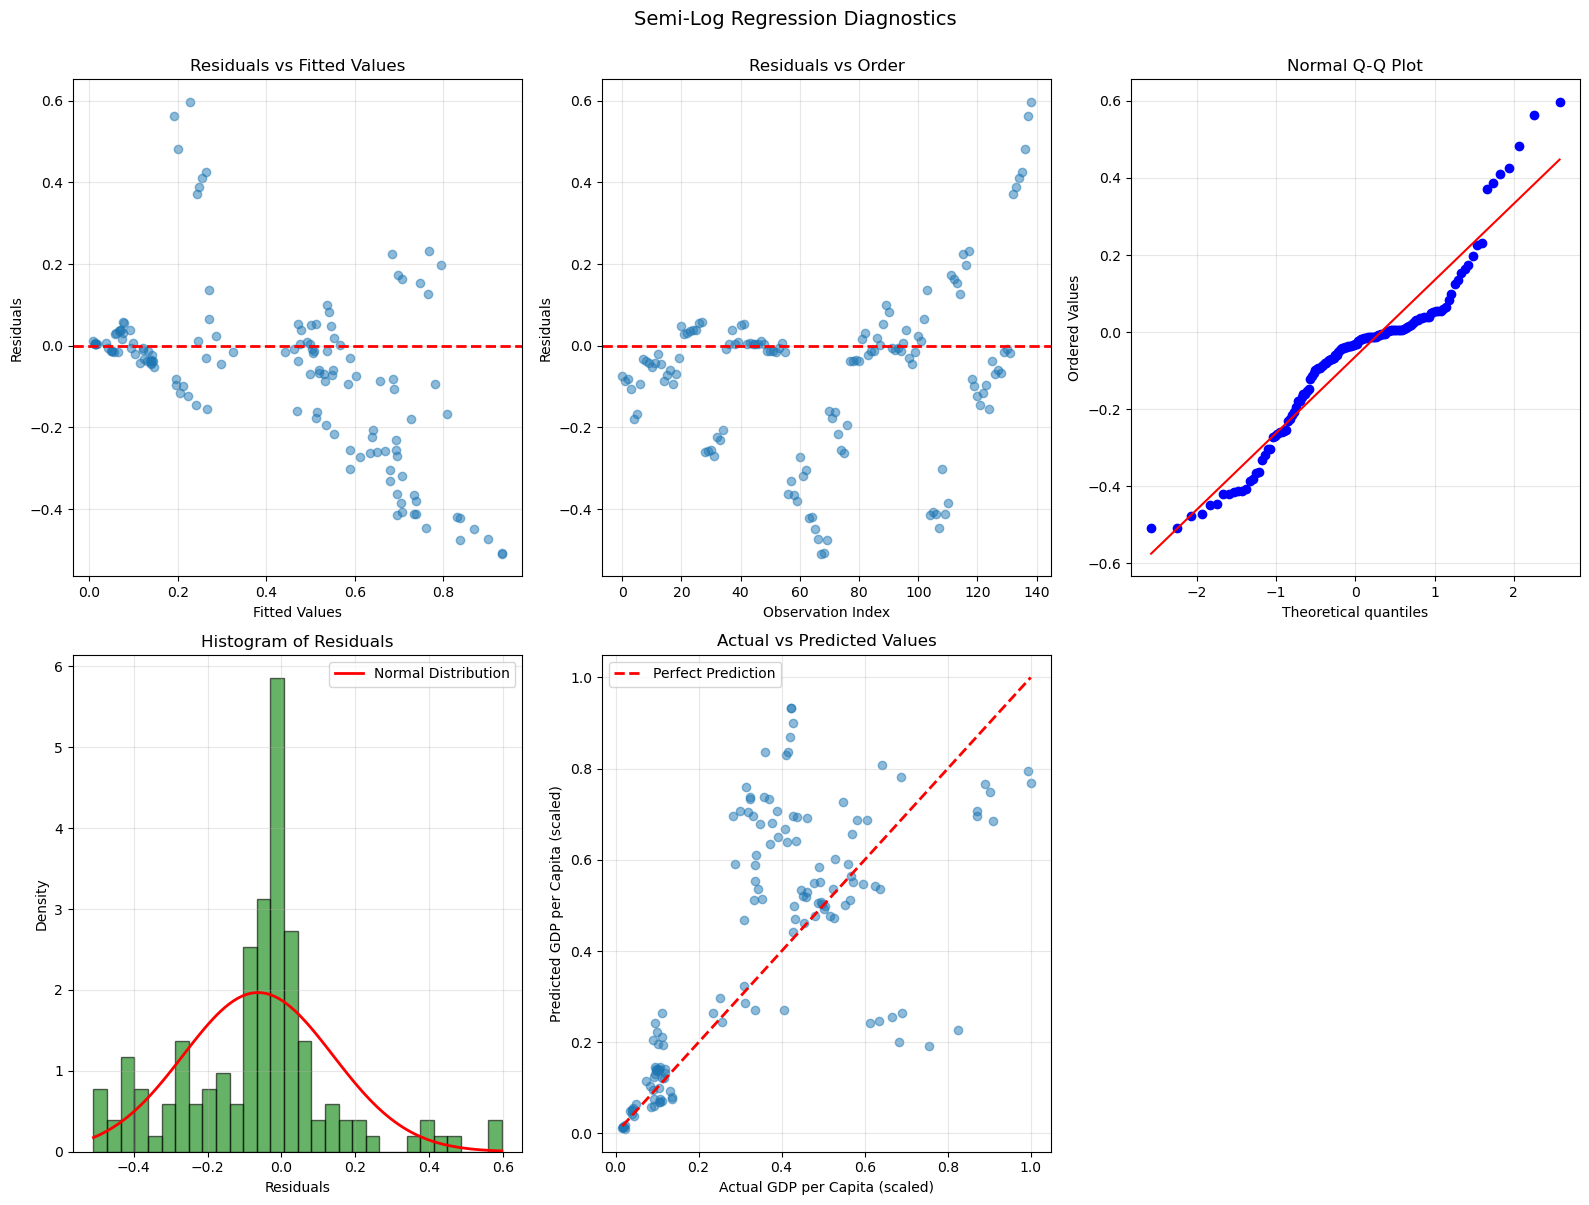

MODEL COMPARISON
Linear Regression Test R^2:      0.4944
Semi-Log Regression Test R^2:    0.2172


In [18]:
def main():
    # Load your cleaned data (adjust path as needed)
    gdp_clean_data = pd.read_csv("top20_gdp_indicators_1980_2022.csv")

    # Selected features for prediction
    feature_cols = [
        'date',
        'population_density',
        'total_population',
        'life_expectancy',
        'infant_mortality',
        'gdp_growth',
        'inflation_rate',
        'age_dependency_ratio'
    ]

    target_col = 'gdp_per_capita'

    # Remove rows with missing values in selected features
    df_clean = gdp_clean_data[feature_cols + [target_col]].dropna()

    # Split into features and target
    X = df_clean[feature_cols].values
    y = df_clean[target_col].values

    # Temporal train-test split (1980-2015 train, 2016-2022 test)
    train_mask, test_mask = train_test_split_temporal(df_clean, train_end_year=2015)

    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]

    print(f"Training set size: {X_train.shape[0]} samples (1980-2015)")
    print(f"Testing set size:  {X_test.shape[0]} samples (2016-2022)")

    # Standardize features for feature importance comparison
    X_train_std, X_test_std = standardize_features(X_train, X_test)

    # ================================ LINEAR REGRESSION ================================
    print("LINEAR REGRESSION")

    # Evaluate model
    intercept_linear, coefficients_linear, mse_train_linear, mse_test_linear, r2_train_linear, r2_test_linear, y_pred_test_linear = evaluate_model(
        X_train, X_test, y_train, y_test,
        feature_cols,
        'linear'
    )

    print(f"Training MSE: {mse_train_linear:.6f}")
    print(f"Testing MSE:  {mse_test_linear:.6f}")
    print(f"Training R^2:  {r2_train_linear:.4f}")
    print(f"Testing R^2:   {r2_test_linear:.4f}\n")

    # Get standardized coefficients for feature importance
    intercept_linear_std, coefficients_linear_std = fit_linear_regression(X_train_std, y_train)

    feature_importance_linear = sorted(
        zip(feature_cols, np.abs(coefficients_linear_std)),
        key=lambda x: x[1],
        reverse=True
    )

    print("Features ranked by importance:")
    for i, (feature, importance) in enumerate(feature_importance_linear, 1):
        print(f"{i}. {feature:25s}: {importance:.6f}")

    # Generate diagnostic plots
    y_pred_test_linear = predict(X_test, intercept_linear, coefficients_linear)
    plot_diagnostics(y_test, y_pred_test_linear, "Linear Regression Diagnostics")

    # ============================== LOGARITHMIC REGRESSION ==============================
    print("SEMI-LOG REGRESSION (log y, linear X)")

    # Evaluate model
    intercept_semilog, coefficients_semilog, mse_train_semilog, mse_test_semilog, r2_train_semilog, r2_test_semilog, y_pred_test_semilog = evaluate_model(
        X_train, X_test, y_train, y_test,
        feature_cols,
        'semilog'
    )

    print(f"Training MSE: {mse_train_semilog:.6f}")
    print(f"Testing MSE:  {mse_test_semilog:.6f}")
    print(f"Training R²:  {r2_train_semilog:.4f}")
    print(f"Testing R²:   {r2_test_semilog:.4f}\n")

    # Get standardized coefficients for feature importance
    intercept_semilog_std, coefficients_semilog_std = fit_semilog_regression(X_train_std, y_train)

    feature_importance_semilog = sorted(
        zip(feature_cols, np.abs(coefficients_semilog_std)),
        key=lambda x: x[1],
        reverse=True
    )

    print("Features ranked by importance:")
    for i, (feature, importance) in enumerate(feature_importance_semilog, 1):
        print(f"{i}. {feature:25s}: {importance:.6f}")

    plot_diagnostics(y_test, y_pred_test_semilog, "Semi-Log Regression Diagnostics")

    # Update comparison
    print("MODEL COMPARISON")
    print(f"Linear Regression Test R^2:      {r2_test_linear:.4f}")
    print(f"Semi-Log Regression Test R^2:    {r2_test_semilog:.4f}")

if __name__ == '__main__':
    main()

## Part 2
(2%) A discussion of the preliminary results:
   - This may include checking of assumptions, generated plots/tables, measures of fit, or other attributes of the analysis
   - It does not have to be fully correct, but as a proof of concept must demonstrate that the group is close to completing the analysis

**Model Comparison & Selection**

**Linear Regression Performance:**

The linear regression model shows strong predictive metrics, Training R² = 0.68, Testing R² = 0.49, and a Testing MSE of 0.029. But the diagnostic plots show that these numbers can be confusing. In the Residuals-vs-Fitted plot, the residuals form obvious clusters and curved shapes instead of spreading randomly, it means the model breaks the linearity and constant-variance assumptions. In the Q-Q plot, the strong S-shape shows that the residuals are not normally distributed. In the Actual-vs-Predicted plot, the points form a curved pattern even show a possible upper limit, which suggests that GDP follows a nonlinear trend that the linear model are not be able to fit. In conclusion, these patterns show that the linear model does not match the true structure of the data, even though its R² values look strong enough.


**Semi-Log Regression Performance:**

On the other hand, the semi-log model shows weaker quantitative performance, Training R² = 0.73, Testing R² = 0.21, and a Testing MSE of 0.045. And the diagnostic plots show that its structure fits the data more closely. In the Residuals-vs-Fitted plot, the residuals seems more randomly spread and evenly centered around zero, which means the model better at satisfies the linearity and constant-variance assumptions. In the Q-Q plot, the points align more closely with the normal distribution line, and the histogram shows a more bell-shaped pattern, suggesting that the errors behave more like random noise. In the Actual-vs-Predicted plot, the points generate a clearer and more stable line along the diagonal, with less curvature and less systematic bias. Overall, these visual patterns shows that the semi-log model captures the relationship in the data better and is more reliable, even though its R² values are lower.

**Recommendation: Use Semi-Log Model**

Based on both the numerical performance of the two models and the results shown in the diagnostic plots, we recommend using the Semi-Log Regression model as the preliminary choice for this phase. Although its testing R² is lower than that of the linear regression model, the residual plot, Q-Q plot, and Actual-vs-Predicted plot show the structure of the data more accurately and produces errors that behave more like random noise. Overall, it looks more reliably than the linear regression model. In contrast, the linear regression model has a higher R², but its diagnostic plots shows clear patterns and systematic bias, which means that it does not reflect the true relationship between GDP and the other variables. Therefore, based on our current  analysis goals, the semi-log model is the more suitable model. If we want to improve performance in the future, we will consider models that work better with nonlinear relationships, such as polynomial regression, random forests, or gradient boosting methods.

**Future Directions:**

The models we used above had trouble dealing with the complex non-linear patterns in GDP data, so we want to try some stronger machine learning models that fit this type of data better. We are considering three main options. First, XGBoost can capture detailed non-linear changes and interactions between features. Second, SVM can use kernel functions (like RBF or Polynomial) to fit more complex decision boundaries. Third, neural networks can learn deeper feature patterns through multiple layers. However, these models also have the risk of overfitting, and we already saw signs of this in the log model. To avoid this, we will use cross-validation and L1/L2 regularization, similar to what we learned in Matrix Methods, to keep the models more stable. Overall, our goal is to find a model that can capture the subtle non-linear relationships between socioeconomic indicators and GDP, while still performing well on new, unseen data.